<h2>Factoring for Breaking RSA</h2>
In this assignment, we will explore first hand why factoring a number is difficult. We will assume that the number  𝑛
  to be factored is semi-prime, i.e, it is the product of two prime factors ( 𝑛=𝑝×𝑞  where  𝑝,𝑞   are both prime).

  First, we will explore trial division factoring. The algorithm is very simple.
<h4>Brute Force Algorithm to Find Smaller Factor</h4>

function find_smaller_factor(n)
   for i = 2 to n-1
      if i divides n 
          return i
    end 
   return None

<h4>(A) Running Time.</h4>
Let  𝑛 be a number whose binary representation has  𝑘 bits. What is a bound on the running time of the brute-force factoring algorithm above as a function of  𝑘, in the worst-case?

My answer - Since maximum number that can be represented by k bits is 2<sup>k</sup>-1, and for loop has to run that many times, run time is exponential in number of bits.

<h4>(B) Brute-Force with Sieving</h4>

We can improve the brute-force algorithm considerably as follows.

The brute force algorithm checks if  𝑛 is divisible by  2 at the very first step. Doing so, precludes to need to check all even numbers.
Once it checks that  𝑛 is not divisible by  3, the algorithm does not need to check multiples of  3.
Once it checks that  𝑛 is not divisible by  5, the algorithm does not need to check multiples of  5.
Once it checks that  𝑛 is not divisible by  7, the algorithm does not need to check multiples of  7.
We can keep going for more primes but we will need to check the utilitiy of doing so.

Modify the brute force algorithm above to check if  𝑛  is divsible by  2,3 or  5 in the first place and then skip all multiples of  2,3,5,7.

Here is the pseudocode

1. check if n is divisible by 2
2. check if n is divisible by 3
3. check if n is divisible by 5
4. check if n is divisible by 7
5. i = 11
6. mod_values = [i%2, i%3, i%5, i%7] # this list stores the values of i %2, .., i%7 respectively
7. while i < n
   7.1  i = i + 2 # increment i to the next odd number
   7.3. # TODO update the mod_values list
   7.4  # if all the numbers in mod_values are non-zero then 
           7.4.1 check if n is divisible by i (if yes then we are done).
8. No factors found -- the number is  prime.

<h2>python * & ** </h2>
<hr>

<h4>The *args will give you all positional arguments as a tuple</h4>

def foo(*args):
    for a in args:
        print(a)        

foo(1)
1

foo(1, 2, 3)
1
2
3

The *args and **kwargs are common idioms to allow an arbitrary number of arguments to functions, as described in the section more on defining functions in the Python tutorial.

The *args will give you all positional arguments as a tuple:

def foo(*args):
    for a in args:
        print(a)        

foo(1)
1

foo(1, 2, 3)
1
2
3


<h4>The **kwargs will give you all keyword arguments as a dictionary</h4>

def bar(**kwargs):
    for a in kwargs:
        print(a, kwargs[a])  

bar(name='one', age=27)
name one
age 27

<h4>Both idioms can be mixed with normal arguments to allow a set of fixed and some variable arguments</h4>
def foo(kind, *args, bar=None, **kwargs):
    print(kind, args, bar, kwargs)

foo(123, 'a', 'b', apple='red')
 123 ('a', 'b') None {'apple': 'red'}

<h4>It is also possible to use this the other way around</h4>

def foo(a, b, c):
    print(a, b, c)

obj = {'b':10, 'c':'lee'}

foo(100, **obj)
100 10 lee

<h2> Python decorators</h2>
<hr>
Python decorators allow you to modify or extend the behavior of functions and methods without changing their actual code. When you use a Python decorator, you wrap a function with another function, which takes the original function as an argument and returns its modified version. This technique provides a simple way to implement higher-order functions in Python, enhancing code reusability and readability.
You can use decorators in various practical scenarios, such as logging, enforcing access control, caching results, or measuring execution time. To create a custom decorator, define a function that takes another function as an argument, creates a nested wrapper function, and returns the wrapper. When applying a decorator, you place @decorator on the line before the function definition.

In [1]:
import numpy as np

# Check if n is divisible by i : Also keep a counter that checks how many times we call this function.
# Important: in your code you must use this function to check divisibility.
def count_calls(f):
    def inner_fun(*args, **kwargs):
        inner_fun.num_calls += 1 # uses python 'closure' to create private field that stays for life cycle of returned object
        return f(*args, **kwargs)
    inner_fun.num_calls = 0
    return inner_fun

# uses count_calls function as decorator  
@count_calls
def is_divisible(n, i):
    if n % i == 0:
        return True
    else: 
        return False

def find_smallest_factor(n):
    is_divisible.num_calls = 0 # reset the counter
    # check divisibility by 2
    if is_divisible(n, 2):
        print('Divisible by 2')
        return 2
    # check if divisible by 3
    if is_divisible(n, 3):
        print('Divisible by 3')
        return 3
    # check if divisible by 5
    if is_divisible(n, 5):
        print('Divisible by 5')
        return 5
    # check if divisible by 7
    if is_divisible(n, 7):
        print('Divisible by 7')
        return 7
    # Let's start our search for factors at i = 11
    i = 11
    # We will sieve using primes 3, 5, 7. In other words factors of these numbers will be "skipped"
    primes = [2, 3, 5, 7] 
    mod_values = [ (i % p) for p in primes] # compute i mod p for each p in the list of prime numbers above
    while i < n:
        # your code here
        is_zero =  (i%2==0 or i%3==0 or i%5==0 or i%7==0)
        if(not is_zero): # 
            if is_divisible(n, i):
                print(f'Divisible by {i}')
                return i # smallest prime factor is found
        i += 2
    return None # We did not find a factor. n is prime

In [2]:
p = find_smallest_factor(77)
print(f'Number of calls to is_divisible = {is_divisible.num_calls}')
assert p == 7, f'Did not find prime factor 7, instead your algorithm finds {p}'
assert is_divisible.num_calls <= 5, f'Your algorithm must find a prime factor for 77 using less than 5 divisibility checks'

Divisible by 7
Number of calls to is_divisible = 4


In [3]:
p = find_smallest_factor(11)
print(f'Number of calls to is_divisible = {is_divisible.num_calls}')
assert p == None, f'Did not find prime factor None, instead your algorithm finds {p}'

Number of calls to is_divisible = 4


In [4]:
p = find_smallest_factor(3589)
print(f'Found prime factor {p}')
print(f'Number of calls to is_divisible = {is_divisible.num_calls}')
assert p == 37, f'Did not find prime factor 37, instead your algorithm finds {p}'
assert is_divisible.num_calls <= 13, f'Your algorithm must find a prime factor for 3689 with less than 13 divisibility checks' 

Divisible by 37
Found prime factor 37
Number of calls to is_divisible = 12


In [6]:
n = 7907 * 7607
p = find_smallest_factor(n)
print(f'Found factor = {p}')
print(f'Number of calls to is_divisible = {is_divisible.num_calls}')
assert p == 7607, f'Did not find prime factor 7607, instead your algorithm finds {p}'
assert is_divisible.num_calls <= 1743, f'Your algorithm must find a prime factor with <= 1745 divisibility checks'

Divisible by 7607
Found factor = 7607
Number of calls to is_divisible = 1743


In [7]:
list_of_semiprimes = [
1401,
3748486951520329,
3752606281089349,
3754961171936341,
3756235832941861,
3758054142736489,
3768343025255113,
3770908285338889,
3789270035360209,
3792097195306729,
3804080660868409,
3809734753698301,
3816606928381453,
3818949174736609,
3820870509943561,
3822840857074201,
3852076309133401,
3876127995012697,
3892629672990589,
3910648469842633,
3920999805125773,
3921744925134109,
3924792228588397,
3931145554413457,
3932125632305329,
3935928816760081,
3961247632016713,
3975676605218881,
3982569750752293,
3982848113442193,
3985942367371729,
3986200067461861,
3990055553157829,
3993390558390133,
3997252998788437,
3998135901643693,
4005313130491789,
4024933426550977,
4036354165122421,
4038083373106021,
4053866502851821,
4067306572005253,
4078847544271369,
4091861946912889,
4099243035596617,
4133788979088253,
4134939693320221,
4142398487623213,
4144730958670993,
4148739776756977,
4179773852763409,
4185730146333961,
4190837552528629,
4194890965293781,
4244075651161417,
4254595003500757,
4299385948797673,
4301923741074121,
]

In [8]:
larger_semi_primes = [
4071703230088892412366704577889,
4077174487336878066180156420913,
4094053397286698473482654556417,
4101876962280933133784935032973,
4116768008174075554551440212201,
4118464001488599202933342898101,
4147085054282417178385925839741,
4199520374935874060660037429949,
4201447187669181909345465904081,
4217217968185891042690716122269,
4265982215678833109847267374413,
4276960721039381017538437010893,
4297398117491445477141849264433,
4308457471676254441614141320113,
4318665979975433623121333937613,
4348710387247934840196147567301,
4350469859956397881296464755633,
4350669852395136207796749980041,
4353730632166509178471552272853,
4364934958079531247768600411733,
4382709417960973622364224001181,
4407498066449976017490450452053,
4440160237236695033093738571121,
4470812069786707724589790729261,
4473006685447434203417464362073,
4505947174116305550519770328493,
4506331456206035322582257570713,
4517928500344319701290035655193,
4561983470742935330053812453913,
4565013457567637164614733701313,
4585984733863428686341532085817,
4595790469861510232344852519141,
4632858772095739089669904044193,
4644781434285276832768688669473,
4690073365881777841992076399393,
4724829586977992218263840967501,
4725019869133272424776227424373,
4752205923965383286154190304221,
4764435726053852491938895756381,
4810894423853388847508420758621,
4846546000539238086954089595097,
4857687447489856168024833391453,
4982826414605095363428438838441,   
840859136266769099141989302482624329,
855840576930709266373830586282510261,
861027643819701747204277038854579437,
871088939311601502891140633368224049,
876368423267217465769505759705453833,
881679905047142429320588481793680161,
890602367374517342786818324571162281,
906470074516552795312247312092686229,
911963995973572045327359020360210893,
943288289991838283035476860320576009,
944620452012152541642183718962300277,
951576904681254216823623938605652857,
961450589952491983605797195651089393,
964050666357935817212991539150079037,
967277736567145456860165852623284681,
968530984526246510271322149219288613,
974401043899706344247628066690771421,
981226989040468082025646298671070233,
987173996184825146489940827731158961,
997841210268749097520592503932722977,
1000501956329468604835922515785485653,
1007869936230522070333869756933805273,
1015619573182240460998581330755083693,
1021081616047239545075046410122475293,
1021775026431207868994862533142687781,
1025858272761026148288194223137761897,
1044135810793395910631723670369957973,
1050464094866115488123433406654950541,
1052285424785035861934473489954661509,
1056871128349446787904114073964205953,
1061185827535031736307801328720295601,
1069000700658564288092454421383559141,
1071033810778602088143562927009490881,
1076873124722141688255023066895194281,
1077525117882554594882117042968349977,
1083013714117195009506742364666379481,
1086545613773109355669486533232229833,
1090989333982502939305859595662258221,
1105290585806660853359903340831677761,
1114536133398125730413308227140211301,
1120973982949479306414447845294990701,
1129229152990601938966431970922508241,
1144031672118032879334904524493262581,
1152448327573964768581549093344816661,
1160935283607233600257774502082792601,
1176153423075023766144324998701733341,
1182136568105127912702737426360063617,
1184130656332325894986471332077695801,
1190842156753902813738209189933879797,
1206452330965591330037140781149281577,
1217378293587704976714062276054717761,
1248739196053094798290642127417720317,
1251559447239398891630697146072701321,
1283800890972422255210765041023225637,
1316872907073608066468826571215294289]

In [9]:
import time
## This is commented out because it takes too long to run. 
## Uncomment it (copy into new cell and uncomment?)
## Increase this to 60 seconds when you are trying the code out to see. But for the testing, we have to disable this cell. 
timeout = 60 # seconds 
orig_timeout=timeout
num_factored = 0
for n in list_of_semiprimes:
    t0 = time.perf_counter()
    p = find_smallest_factor(n)
    num_factored += 1
    t1 = time.perf_counter()
    print(f'{n} = {p} * {n//p}')
    timeout = timeout - (t1 - t0)
    if timeout < 0:
        break

print(f'{num_factored} numbers were factored within {orig_timeout} seconds')

Divisible by 3
1401 = 3 * 467


KeyboardInterrupt: 

<h2>Pollard's Rho Algorithm</h2>
Pollard's rho algorithm is a very interesting approach that can factor numbers faster than trial division. Nevertheless, it is exponential time in practice and falls short of factoring really large numbers.
<h4>Basic Ideas</h4>
We are attempting to find the prime factors of a large semi-prime number  𝑛. Trial division runs over numbers  2,3,5,… and tests each of them for divisibility by  𝑛.

For Pollard's rho algorithm, we will instead switch to computing  𝐺𝐶𝐷(𝑘𝑖,𝑛) for a series of numbers  𝑘1,…,𝑘𝑚
  that we will generate in a careful manner.

Observation: If  𝑘≠𝑛 and  𝐺𝐶𝐷(𝑘,𝑛)≠1 then  𝐺𝐶𝐷(𝑘,𝑛) is a factor of  𝑛.

Clearly,  𝐺𝐶𝐷(𝑘,𝑛) is divisible by  𝑛 (as well as  𝑘 ). However, computing GCD is more expensive than computing if  𝑘 is divisible by  𝑛. What is the advantage?

<h4>Example</h4>


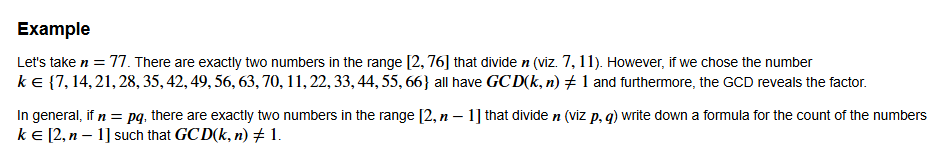

My answer - if n is product of 2 prime numbers p,q then within range [2,n-1] only p,q will divide n. Prrof by contradiction - let another number x also divide 2 and lie in [2,n-1]. Then p*q is divisible by x => either one of p or q is not prime number which leads to contradiction => x cannot exist => only p,q divide the semi-prime number n. k = p*1,p*2,...,p*q will all give GCD(k,n)!=1 also for k=q*1, q*2,..,q*(p-1) will all give GCD(k,n)!=1 { we go only till p-1 since q*p has already been considered earlier } => total q+p-1 numbers in [2,n] will give GCD with n = 1.

<h2>Searching for a factor: version 1</h2>

Let's try to find a factor by generating (pseudo) random numbers  𝑘1,…,𝑘𝑚 and checking of  𝐺𝐶𝐷(𝑘𝑖,𝑛)≠1 for any  𝑘. For simplicity, we will provide  𝑚 as an input.

Pseudorandom sequencs can be generated in many ways. A simple approach is to use a polynomial  𝑓(𝑥)=(𝑥power2+𝑐) mod 𝑛
  for a small number  𝑐 , typically  𝑐=1. Our pseudo random sequence is typically given by
𝑓(2),𝑓(𝑓(2)),𝑓(𝑓(𝑓(2))),...,𝑓 to the power(𝑚)(2)

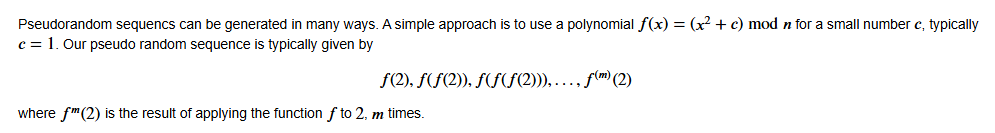



In [10]:
# here is the code for GCD
def gcd(m, n):
    if (m < n):
        (m, n) = (n, m)
    while n > 0:
        (m, n) = (n, m%n)
    return m

# use f to generate pseudo random number
# it requires the number n as an input as well 
def f(x, n): 
    return (x * x + 1) % n


Implement a function: pseudo_random_gcd_factorization(n, m=100000), where n is the number to factorize and m is the number of random numbers we will try.

The pseudo code is shown below

    initialize x to 2
    iterate m times
       Test if GCD(x, n) reveals a prime factor of n
            if yes, return prime factor.
       x = f(x, n) # compute f(x,n) -- f is defined in the previous cell
    return None if no prime factor found

In [25]:

def pseudo_random_gcd_factorization(n, m=100000): 
    # by default try 100,000 numbers
    x = 2
    # print(f'finding prime factor for n={n}')
    for y in range(m):
        # print(f'x={x},n={n}')
        g_c_d = gcd(x,n)
        if g_c_d == 1:
            x = f(x,n)
            continue
        # print(f'g_c_d={g_c_d}')
        factr= find_smallest_factor(g_c_d)
        # print(f'factr={factr}')
        if  factr == None:
            return g_c_d
        x = f(x,n)
    return None
    

In [26]:
import time

timeout = 15 # seconds 
num_factored = 0
for n in list_of_semiprimes:
    t0 = time.perf_counter()
    p = pseudo_random_gcd_factorization(n)
    if p != None:
        assert n % p == 0, f'prime factor {p} is incorrect'
        assert p != 1 and p != n, f'factor {p} cannot be trivial'
        print(f'{n} = {p} * {n//p}')
        num_factored += 1
    else:
        print(f'Failed to factor {n}')
    t1 = time.perf_counter()
    timeout = timeout - (t1 - t0)
    if timeout < 0:
        break

print(f'{num_factored} numbers were factored within 15 seconds')

Failed to factor 1401
Failed to factor 3748486951520329
Failed to factor 3752606281089349
Failed to factor 3754961171936341
Failed to factor 3756235832941861
Failed to factor 3758054142736489
Failed to factor 3768343025255113
Failed to factor 3770908285338889
Failed to factor 3789270035360209
Failed to factor 3792097195306729
Failed to factor 3804080660868409
Failed to factor 3809734753698301
Failed to factor 3816606928381453
Failed to factor 3818949174736609
Failed to factor 3820870509943561
Failed to factor 3822840857074201
Failed to factor 3852076309133401
Failed to factor 3876127995012697
Failed to factor 3892629672990589
Failed to factor 3910648469842633
Failed to factor 3920999805125773
Failed to factor 3921744925134109
Failed to factor 3924792228588397
Failed to factor 3931145554413457
Failed to factor 3932125632305329
0 numbers were factored within 15 seconds


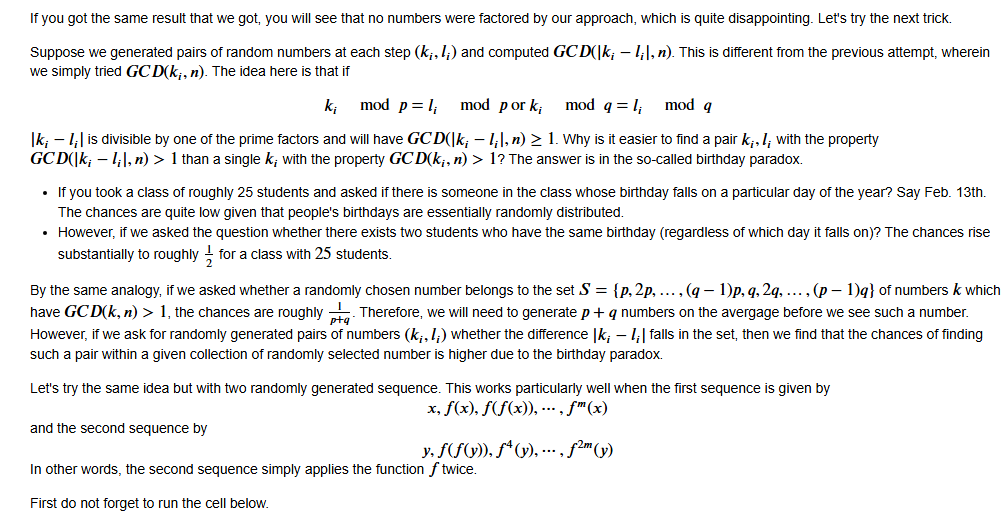

In [28]:
from random import randrange, getrandbits
# here is the code for GCD
def gcd(m, n):
    if (m < n):
        (m, n) = (n, m)
    while n > 0:
        (m, n) = (n, m%n)
    return m

# use f to generate pseudo random number
# it requires the number n as an input as well 
def f(x, n): 
    return (x*x+1)%n

# use g to generate a second pseudo random sequence

def g(y, n):
    return f(f(y,n),n)

# pseudo random GCD-based factorization

Implement a function: pseudo_random_gcd_factorization(n, m=100000), where n is the number to factorize and m is the number of random numbers we will try.

The pseudo code is shown below

    initialize x to 2 and y to 2
    iterate m times
       x = f(x,n)
       y = g(y, n)
       Test if GCD(|x-y|, n) reveals a prime factor of n
            if yes, return prime factor.
    return None if no prime factor found

In [46]:
def pseudo_random_difference_gcd_factorization(n, m=100000): 
    # by default try 100,000 numbers
    # print(f'n={n}')
    x=2
    y=2
    for z in range(m):
        x = f(x,n)
        y = g(y,n)
        g_c_d = gcd(abs(x-y), n)
        if g_c_d == 1:
            continue
        if g_c_d != None and n!=g_c_d:
            return g_c_d
    return None

In [47]:
pseudo_random_difference_gcd_factorization(1401)

3

In [48]:
import time

timeout = 15 # seconds 
num_factored = 0
for n in list_of_semiprimes:
    t0 = time.perf_counter()
    p = pseudo_random_difference_gcd_factorization(n)
    if p != None:
        assert n % p == 0, f'prime factor {p} is incorrect'
        assert p > 1 and p < n, f'factor {p} cannot be trivial'
        print(f'{n} = {p} * {n//p}')
        num_factored += 1
    else:
        print(f'Failed to factor {n}')
    t1 = time.perf_counter()
    timeout = timeout - (t1 - t0)
    if timeout < 0:
        break

print(f'{num_factored} numbers were factored within 15 seconds')

1401 = 3 * 467
3748486951520329 = 57142403 * 65599043
3752606281089349 = 926867 * 4048699847
3754961171936341 = 61797647 * 60762203
3756235832941861 = 926867 * 4052615783
3758054142736489 = 971207 * 3869467727
3768343025255113 = 64697219 * 58245827
3770908285338889 = 1035107 * 3643013027
3789270035360209 = 61557047 * 61557047
3792097195306729 = 57807203 * 65599043
3804080660868409 = 61797647 * 61557047
3809734753698301 = 984563 * 3869467727
3816606928381453 = 986339 * 3869467727
3818949174736609 = 61797647 * 61797647
3820870509943561 = 65599043 * 58245827
3822840857074201 = 64697219 * 59088179
3852076309133401 = 926867 * 4156018403
3876127995012697 = 65599043 * 59088179
3892629672990589 = 926867 * 4199771567
3910648469842633 = 968459 * 4038011387
3920999805125773 = 968459 * 4048699847
3921744925134109 = 971207 * 4038011387
3924792228588397 = 968459 * 4052615783
3931145554413457 = 64697219 * 60762203
3932125632305329 = 971207 * 4048699847
3935928816760081 = 971207 * 4052615783
396124763

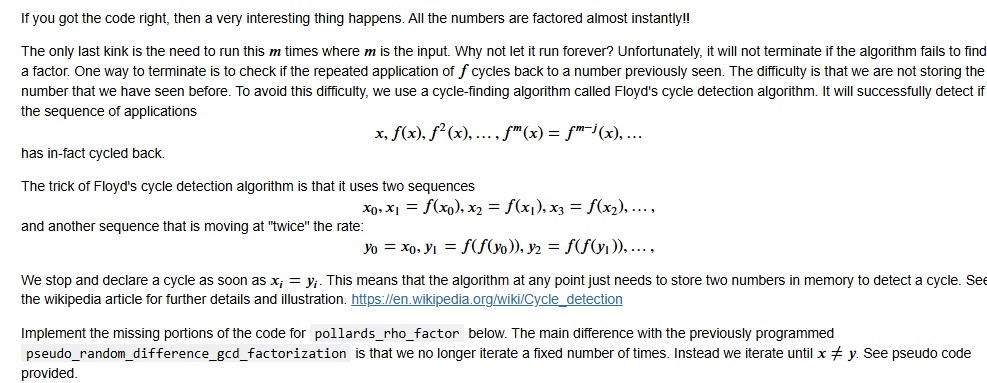

In [49]:
def gcd(m, n):
    if (m < n):
        (m, n) = (n, m)
    while n > 0:
        (m, n) = (n, m%n)
    return m

def pollards_rho_factor(n, a=1):
    def f(x):
        return (x*x + a)%n
    x = f(2) # initialize x and y
    y = f(f(2))
    
    while x != y:
        # compute gcd of |x-y| and n, check if a prime factor is found
        x = f(x)
        y = f(f(y))
        g_c_d = gcd(abs(x-y), n)
        if g_c_d == 1:
            continue
        if g_c_d != None and n!=g_c_d:
            return g_c_d
    print('Failed')
    return None

In [50]:
import time

timeout = 15 # seconds 
num_factored = 0
for n in list_of_semiprimes:
    t0 = time.perf_counter()
    p = pollards_rho_factor(n)
    if p != None:
        assert n%p == 0, f'{p} is not a factor of {n}'
        print(f'{n} = {p} * {n//p}')
        num_factored += 1
    t1 = time.perf_counter()
    timeout = timeout - (t1 - t0)
    if timeout < 0:
        break

print(f'{num_factored} numbers were factored within 15 seconds')

1401 = 3 * 467
3748486951520329 = 57142403 * 65599043
3752606281089349 = 926867 * 4048699847
3754961171936341 = 61797647 * 60762203
3756235832941861 = 926867 * 4052615783
3758054142736489 = 971207 * 3869467727
3768343025255113 = 64697219 * 58245827
3770908285338889 = 1035107 * 3643013027
3789270035360209 = 61557047 * 61557047
3792097195306729 = 57807203 * 65599043
3804080660868409 = 61797647 * 61557047
3809734753698301 = 984563 * 3869467727
3816606928381453 = 986339 * 3869467727
3818949174736609 = 61797647 * 61797647
3820870509943561 = 65599043 * 58245827
3822840857074201 = 64697219 * 59088179
3852076309133401 = 926867 * 4156018403
3876127995012697 = 65599043 * 59088179
3892629672990589 = 926867 * 4199771567
3910648469842633 = 968459 * 4038011387
3920999805125773 = 968459 * 4048699847
3921744925134109 = 971207 * 4038011387
3924792228588397 = 968459 * 4052615783
3931145554413457 = 64697219 * 60762203
3932125632305329 = 971207 * 4048699847
3935928816760081 = 971207 * 4052615783
396124763

The resulting algorithm is called Pollard's Rho algorithm. It is a very fast algorithm especially when one of the factors is small. In practice, it is much faster than trial division. However, many aspects of the algorithm are quite mysterious and not well understood. For instance, the algorithm depends very much on the pseudorandom generator and some of them are much better than the others. It is not clear why this is so.
If we run pollard's rho algorithm fro larger primes - we will notice that even Pollard's Rho algorithm will struggle to factor really large numbers.

In [51]:
## We commented out this cell since it will take forever to run. Please uncomment and try out. 
# You may have to cut and paste it into a new cell to do that. 
#import time

timeout = 180 # seconds -- increase the timeout if you wish
num_factored = 0
for n in larger_semi_primes:
    t0 = time.perf_counter()
    p = pollards_rho_factor(n)
    if p != None:
        assert n%p == 0, f'{p} is not a factor of {n}'
        print(f'{n} = {p} * {n//p}')
        num_factored += 1
    t1 = time.perf_counter()
    timeout = timeout - (t1 - t0)
    if timeout < 0:
        break
print(f'{num_factored} numbers were factored within 180 seconds')

4071703230088892412366704577889 = 4192314883787 * 971230297093247747
4077174487336878066180156420913 = 4342140047327 * 938978117448507119
4094053397286698473482654556417 = 3659550641003 * 1118731177378819139
4101876962280933133784935032973 = 4223382419759 * 971230297093247747
4 numbers were factored within 180 seconds
